In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [2]:
class HappinessEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self):
        super(HappinessEnv, self).__init__()
        self.grid_size = (5, 5)  
        self.num_states = self.grid_size[0] * self.grid_size[1]
        self.action_space = spaces.Discrete(4)  
        self.observation_space = spaces.Box(
            low=0, high=max(self.grid_size), shape=(2,), dtype=np.int32
        )  

        self.goal_state = (4, 4)  

        self.rewards = np.zeros(self.grid_size)
        self.rewards[4, 4] = 50 
        self.rewards[2, 2] = -5  
        self.rewards[1, 1] = -3  
        self.rewards[3, 3] = 20
        self.state = None

    def reset(self, seed=None, options=None):
        """
        Reset the environment to the initial state.
        """
        super().reset(seed=seed)
        self.state = (0, 0)
        self.goal_state = (4, 4)  

        self.rewards = np.zeros(self.grid_size)
        self.rewards[4, 4] = 50 
        self.rewards[3, 3] = 20  
        self.rewards[2, 2] = -5  
        self.rewards[1, 1] = -3  
        
        return np.array(self.state, dtype=np.int32), {}

    def step(self, action):
        """
        Execute one timestep within the environment.
        """
        if action not in range(4):  
            raise ValueError(f"Invalid action: {action}")

        i, j = self.state
        if action == 0:  # Up
            next_state = (max(0, i - 1), j)
        elif action == 1:  # Down
            next_state = (min(self.grid_size[0] - 1, i + 1), j)
        elif action == 2:  # Right
            next_state = (i, min(self.grid_size[1] - 1, j + 1))
        elif action == 3:  # Left
            next_state = (i, max(0, j - 1))
        else:
            raise ValueError(f"Unexpected action: {action}")

        self.state = next_state
        reward = self.rewards[next_state]

        if reward > 0:  
            self.rewards[next_state] = 0

        found = self.state == self.goal_state
        return np.array(self.state, dtype=np.int32), reward, found

In [3]:
# States definition
statesMap = {(0, 0): 0, (0, 1): 1, (0, 2): 2, (0, 3): 3, (0, 4): 4,
          (1, 0): 5, (1, 1): 6, (1, 2): 7, (1, 3): 8, (1, 4): 9,
          (2, 0): 10, (2, 1): 11, (2, 2): 12, (2, 3): 13, (2, 4): 14,
          (3, 0): 15, (3, 1): 16, (3, 2): 17, (3, 3): 18, (3, 4): 19,
          (4, 0): 20, (4, 1): 21, (4, 2): 22, (4, 3): 23, (4, 4): 24}

In [4]:

def sarsa(env, episodes=1000, alpha=0.1, gamma=0.99, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.1):

    Q = np.zeros((env.grid_size[0] * env.grid_size[1], env.action_space.n))
    
    rewards_per_episode = []
    epsilon_values = []

    for episode in range(episodes):
        state, _ = env.reset()
        state = tuple(state)
        action = np.random.choice(env.action_space.n) if np.random.rand() < epsilon else np.argmax(Q[statesMap[state]])

        total_reward = 0

        while True:

            next_state, reward, done = env.step(action)
            next_state = tuple(next_state)

            next_action = np.random.choice(env.action_space.n) if np.random.rand() < epsilon else np.argmax(Q[statesMap[next_state]])

            Q[statesMap[state]][action] += alpha * ( reward + gamma * Q[statesMap[next_state]][next_action] - Q[statesMap[state]][action] )

            state = next_state
            action = next_action
            total_reward += reward

            if done:
                break

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards_per_episode.append(total_reward)
        epsilon_values.append(epsilon)

    return Q, rewards_per_episode, epsilon_values

In [5]:
def printQTable(Q):
    for row in Q:
        print("\t".join(map(str, row)))

In [6]:
# Train the agent
env = HappinessEnv()
initial_Q = np.zeros((env.grid_size[0] * env.grid_size[1], env.action_space.n)) 
print("Initial Q-Table:")
printQTable(initial_Q)


Initial Q-Table:
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0
0.0	0.0	0.0	0.0


In [7]:
Q, rewards_per_episode, epsilon_values = sarsa(env, episodes=1000)
print("\nTrained Q-Table:")
printQTable(Q)


Trained Q-Table:
42.10792731549793	46.81741756760039	21.262414051179956	41.140483993833044
-0.13906162657825194	6.240521997232932	0.8210187988399843	38.45518494220863
-0.5264950676552853	-0.4086904537314763	3.8847503395870864	-0.9884787033257083
2.6383044419914765	12.297432334261803	0.763275263719079	-0.2662450492565313
0.7320519023455114	5.052059299112161	0.24855705013350016	0.6445258737991566
40.11871758455102	48.15671015331682	35.3997699303693	45.04839521101268
0.9435386256688534	47.910304753435085	-2.199775071423791	4.214218127607075
-0.6618870067133198	-3.1689733385866976	15.7979076217516	-3.3671742557713493
0.25618032083226827	41.6333122298658	3.0169443416368154	-0.14454051649140143
0.29553037325874826	17.537575484493587	1.047555022361617	2.8737180802119973
44.896631906509	49.28002769115904	44.650464120559754	44.75430020633506
13.694114134871208	50.89506995906462	11.554076508160719	14.532816849481108
2.969084904264159	27.87843683897439	47.457736125469914	20.035946366763028
16.62

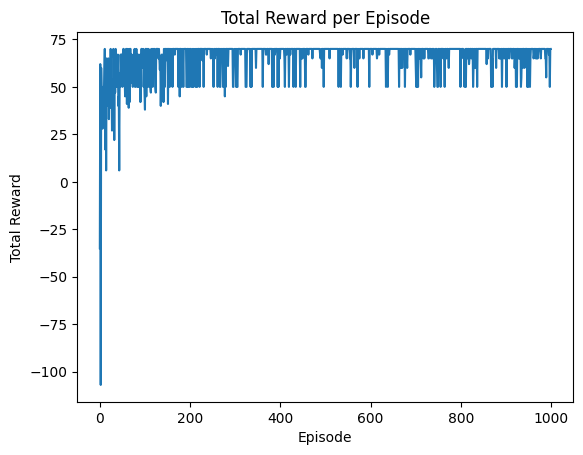

In [8]:
plt.plot(rewards_per_episode)
plt.title("Total Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

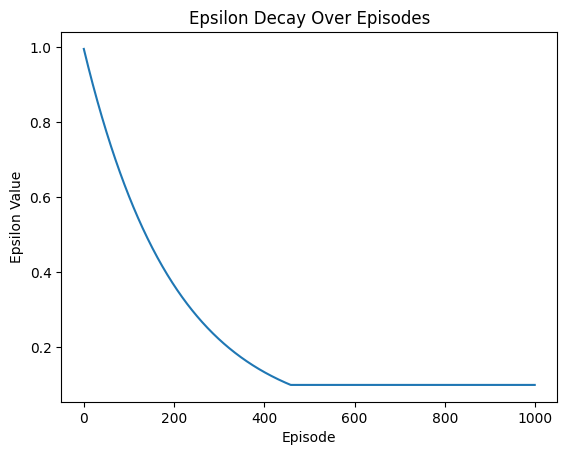

In [9]:
plt.plot(epsilon_values)
plt.title("Epsilon Decay Over Episodes")
plt.xlabel("Episode")
plt.ylabel("Epsilon Value")
plt.show()

Episode  0
Current Position: [1 0], Action: Down, Reward: 0.0
Current Position: [2 0], Action: Down, Reward: 0.0
Current Position: [3 0], Action: Down, Reward: 0.0
Current Position: [3 1], Action: Right, Reward: 0.0
Current Position: [3 2], Action: Right, Reward: 0.0
Current Position: [3 3], Action: Right, Reward: 20.0
Current Position: [4 3], Action: Down, Reward: 0.0
Current Position: [4 4], Action: Right, Reward: 50.0
Episode  1
Current Position: [1 0], Action: Down, Reward: 0.0
Current Position: [2 0], Action: Down, Reward: 0.0
Current Position: [3 0], Action: Down, Reward: 0.0
Current Position: [3 1], Action: Right, Reward: 0.0
Current Position: [3 2], Action: Right, Reward: 0.0
Current Position: [3 3], Action: Right, Reward: 20.0
Current Position: [4 3], Action: Down, Reward: 0.0
Current Position: [4 4], Action: Right, Reward: 50.0
Episode  2
Current Position: [1 0], Action: Down, Reward: 0.0
Current Position: [2 0], Action: Down, Reward: 0.0
Current Position: [3 0], Action: Down

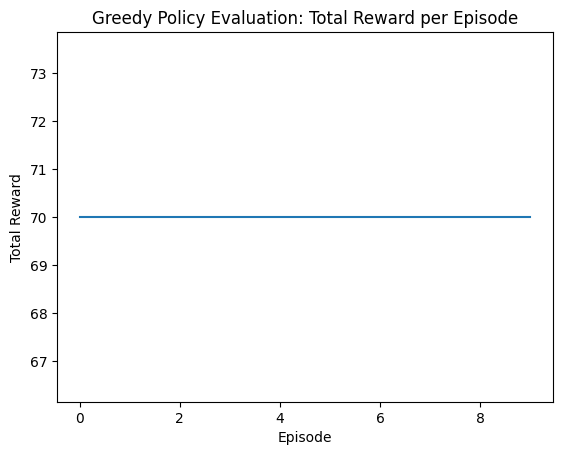

In [10]:
greedy_rewards = []
action_map = {
    0: "Up",
    1: "Down",
    2: "Right",
    3: "Left"
}

for i in range(10):
    state, _ = env.reset()
    state = tuple(state)
    total_reward = 0

    print("Episode ",i)

    while True:

        action = np.argmax(Q[statesMap[state]])
        next_state, reward, done = env.step(action)
        print(f"Current Position: {next_state}, Action: {action_map[action]}, Reward: {reward}")

        total_reward += reward

        if done:
            break
        state = tuple(next_state)

    greedy_rewards.append(total_reward)

plt.plot(greedy_rewards)
plt.title("Greedy Policy Evaluation: Total Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()


In [11]:
best_params = None
best_performance = float('-inf')
results = []

for alpha in [0.1,0.01, 0.001]:
    for gamma in [0.90, 0.95, 0.99]:
        for epsilon_decay in [0.995, 0.99, 0.98]:
            Q, rewards_per_episode, _ = sarsa(env, alpha=alpha, gamma=gamma, epsilon_decay=epsilon_decay, episodes=1000)

            avg_reward = np.mean(rewards_per_episode[-100:])
            results.append((gamma, epsilon_decay, avg_reward))

            print(f"Testing Alpha={alpha}, γ={gamma}, Epsilon Decay={epsilon_decay}, Reward={avg_reward}")
            if avg_reward > best_performance:
                best_performance = avg_reward
                best_params = (alpha, gamma, epsilon_decay)

print("Best Parameters:")
print(f"Aplha={best_params[0]}, γ={best_params[1]}, Epsilon Decay={best_params[2]} (Average Reward: {best_performance})")


Testing Alpha=0.1, γ=0.9, Epsilon Decay=0.995, Reward=68.05
Testing Alpha=0.1, γ=0.9, Epsilon Decay=0.99, Reward=68.31
Testing Alpha=0.1, γ=0.9, Epsilon Decay=0.98, Reward=68.67
Testing Alpha=0.1, γ=0.95, Epsilon Decay=0.995, Reward=68.18
Testing Alpha=0.1, γ=0.95, Epsilon Decay=0.99, Reward=69.46
Testing Alpha=0.1, γ=0.95, Epsilon Decay=0.98, Reward=68.23
Testing Alpha=0.1, γ=0.99, Epsilon Decay=0.995, Reward=65.42
Testing Alpha=0.1, γ=0.99, Epsilon Decay=0.99, Reward=68.94
Testing Alpha=0.1, γ=0.99, Epsilon Decay=0.98, Reward=67.46
Testing Alpha=0.01, γ=0.9, Epsilon Decay=0.995, Reward=69.1
Testing Alpha=0.01, γ=0.9, Epsilon Decay=0.99, Reward=68.91
Testing Alpha=0.01, γ=0.9, Epsilon Decay=0.98, Reward=69.56
Testing Alpha=0.01, γ=0.95, Epsilon Decay=0.995, Reward=68.87
Testing Alpha=0.01, γ=0.95, Epsilon Decay=0.99, Reward=69.57
Testing Alpha=0.01, γ=0.95, Epsilon Decay=0.98, Reward=69.27
Testing Alpha=0.01, γ=0.99, Epsilon Decay=0.995, Reward=67.71
Testing Alpha=0.01, γ=0.99, Epsilo

Trained Q-Table with Best Parameters:
[[ 3.01941213e+01  3.81653824e+01  9.56520570e+00  3.42199476e+01]
 [-5.23024784e-01 -3.45788133e+00  1.57685164e+00  2.52086321e+01]
 [ 2.16872240e-01 -7.93693666e-01  4.11726669e+00 -6.85898423e-01]
 [ 1.67717143e+00  2.37988539e+00  1.06900258e+01 -3.03185364e-02]
 [ 1.13943165e+00  1.99716909e+01  1.94623679e+00  6.35201549e-02]
 [ 3.33785530e+01  4.11968345e+01  1.57151479e+01  3.42051010e+01]
 [-7.92684000e-01  3.14499497e+00 -1.10561075e+00  3.27251032e+01]
 [-1.28631635e-01 -4.58684391e+00  2.12739708e+00 -3.11345580e+00]
 [ 1.59655979e-02  1.02564763e+01  1.66340187e+01 -9.16189152e-01]
 [ 1.44753700e+00  3.65076075e+01  6.71858631e+00  2.24114578e+00]
 [ 3.62533401e+01  3.95628779e+01  4.43875281e+01  4.02147904e+01]
 [-2.97776772e+00  4.78424571e+01 -3.03060881e+00  1.30294883e+01]
 [-8.29989057e-01  1.08149652e+01  3.19064198e+01  7.68501218e+00]
 [ 4.42996493e+00  5.08600703e+01  8.50225266e+00  1.60438335e+00]
 [ 7.34035520e+00  4.577

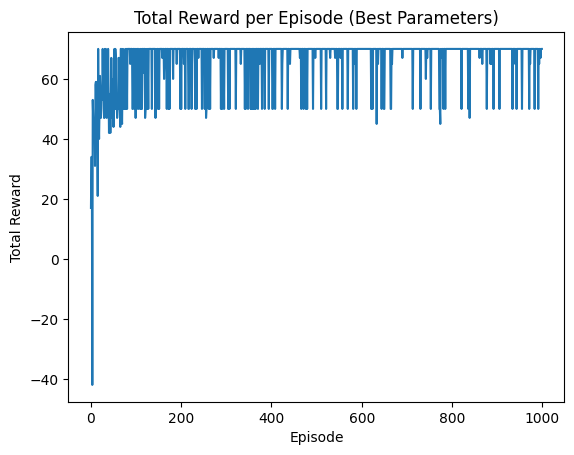

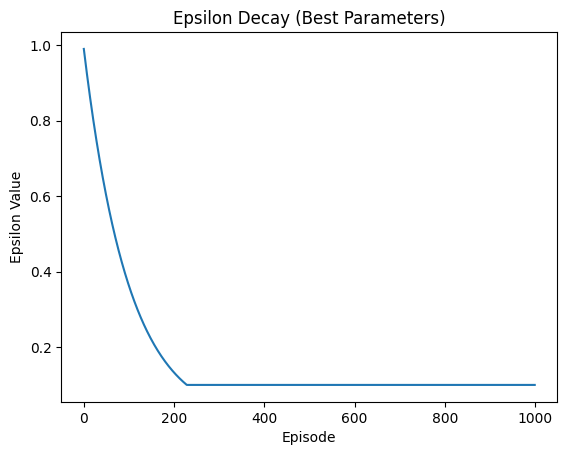

In [12]:
# Retrain with best parameters
alpha, gamma, epsilon_decay = best_params
Q, rewards_per_episode, epsilon_values = sarsa(env, gamma=gamma, epsilon_decay=epsilon_decay, episodes=1000)

# Evaluation results
print("Trained Q-Table with Best Parameters:")
print(Q)

# Plot total reward per episode
plt.plot(rewards_per_episode)
plt.title("Total Reward per Episode (Best Parameters)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

# Plot epsilon decay
plt.plot(epsilon_values)
plt.title("Epsilon Decay (Best Parameters)")
plt.xlabel("Episode")
plt.ylabel("Epsilon Value")
plt.show()

In [13]:
printQTable(Q)

30.194121321880917	38.16538241587889	9.565205703731731	34.21994760751203
-0.5230247843796658	-3.45788133004212	1.5768516369073393	25.208632134337872
0.21687223966798327	-0.793693666145522	4.117266693246854	-0.6858984231703414
1.67717142696099	2.379885385857582	10.690025833484325	-0.030318536356834153
1.139431646307607	19.971690948440866	1.9462367905075921	0.0635201549406163
33.37855298074912	41.19683453307288	15.715147942936015	34.205100954679054
-0.7926840004308701	3.1449949721014994	-1.105610751434837	32.725103248710724
-0.1286316345654406	-4.586843910450311	2.1273970824701007	-3.1134558002028454
0.01596559790128421	10.256476347812905	16.63401869123672	-0.9161891517927492
1.447537001895706	36.50760754667295	6.718586305538424	2.2411457803726975
36.25334012238496	39.562877861357045	44.38752806118532	40.21479043462331
-2.9777677240927245	47.84245711174863	-3.030608812462837	13.029488322428737
-0.829989056714767	10.814965155021214	31.906419814614686	7.68501217975614
4.429964930904163	50.